# Neuroevolution with NEAT

We will start by installing the ```neat-python``` library, which provides an implementation of NEAT, and the ```networkx``` library to draw the resulting network

In [7]:
import neat
import random
import networkx as nx

The problem is a variant of the XOR problem with one additional input.

We have three inputs $x_1, x_2, x_3$ and two outputs $y_1 = x_1 \oplus x_2$ and $y_2 = \neg x_3$.

Part of the following code is adapted from a ```neat-python``` example

In [8]:
xor_inputs = [(0.0, 0.0, 0.0), (0.0, 0.0, 1.0),
              (0.0, 1.0, 0.0), (0.0, 1.0, 1.0),
              (1.0, 0.0, 0.0), (1.0, 0.0, 1.0),
              (1.0, 1.0, 0.0), (1.0, 1.0, 1.0)]
xor_outputs = [(0.0, 1.0), (0.0, 0.0),
               (1.0, 1.0), (1.0, 0.0),
               (1.0, 1.0), (1.0, 0.0),
               (0.0, 1.0), (0.0, 0.0)]

To define how to eval the genomes we generate the network starting from the genome using ```nn.FeedFOrwardNetwork.create```, and we can use the method ```activate``` to compute the outputs of the net.

In [9]:
def eval_genomes(genomes, config):
    for genome_id, genome in genomes:
        genome.fitness = 16.0
        net = neat.nn.FeedForwardNetwork.create(genome, config)
        for xi, xo in zip(xor_inputs, xor_outputs):
            output = net.activate(xi)
            genome.fitness -= (output[0] - xo[0]) ** 2
            genome.fitness -= (output[1] - xo[1]) ** 2

The ```neat-python``` library **requires** a (non-trivial) configuration file (see ```neat_config.txt```)

In [10]:
config = neat.Config(neat.genome.DefaultGenome,
                     neat.reproduction.DefaultReproduction,
                     neat.species.DefaultSpeciesSet,
                     neat.stagnation.DefaultStagnation,
                     "neat_config.txt")

We can now create the initial population (based on the given configuration)

In [11]:
population = neat.Population(config)

We evolve the population from $500$ generations

In [12]:
random.seed(0)
winner = population.run(eval_genomes, 500)

We can print the best network found:

In [13]:
print(f'Best genome:\n{winner}')

Best genome:
Key: 42437
Fitness: 15.967688162021915
Nodes:
	0 DefaultNodeGene(key=0, bias=-3.9465778216768412, response=1.0, activation=sigmoid, aggregation=sum)
	1 DefaultNodeGene(key=1, bias=2.4637591529704137, response=1.0, activation=sigmoid, aggregation=sum)
	5995 DefaultNodeGene(key=5995, bias=-0.9474096907952682, response=1.0, activation=sigmoid, aggregation=sum)
Connections:
	DefaultConnectionGene(key=(-3, 1), innovation=6, weight=-8.720045024886964, enabled=True)
	DefaultConnectionGene(key=(-2, 0), innovation=20682, weight=-2.417698989604432, enabled=True)
	DefaultConnectionGene(key=(-2, 5995), innovation=17613, weight=2.167908179373512, enabled=True)
	DefaultConnectionGene(key=(-1, 0), innovation=21147, weight=-1.6785953614017952, enabled=True)
	DefaultConnectionGene(key=(-1, 5995), innovation=17615, weight=1.5771910913516942, enabled=True)
	DefaultConnectionGene(key=(5995, 0), innovation=17614, weight=6.766005366081795, enabled=True)


And the outputs of the network:

In [14]:
print('\nOutput:')
winner_net = neat.nn.FeedForwardNetwork.create(winner, config)
for xi, xo in zip(xor_inputs, xor_outputs):
    output = winner_net.activate(xi)
    print(f"input {xi}, expected output {xo}, got {output}")


Output:
input (0.0, 0.0, 0.0), expected output (0.0, 1.0), got [3.6121497707568283e-09, 0.9999955330300013]
input (0.0, 0.0, 1.0), expected output (0.0, 0.0), got [3.6121497707568283e-09, 2.5980520230948646e-14]
input (0.0, 1.0, 0.0), expected output (1.0, 1.0), got [0.8735948336153322, 0.9999955330300013]
input (0.0, 1.0, 1.0), expected output (1.0, 0.0), got [0.8735948336153322, 2.5980520230948646e-14]
input (1.0, 0.0, 0.0), expected output (1.0, 1.0), got [0.9867782765511538, 0.9999955330300013]
input (1.0, 0.0, 1.0), expected output (1.0, 0.0), got [0.9867782765511538, 2.5980520230948646e-14]
input (1.0, 1.0, 0.0), expected output (0.0, 1.0), got [0.0016849004248986963, 0.9999955330300013]
input (1.0, 1.0, 1.0), expected output (0.0, 0.0), got [0.0016849004248986963, 2.5980520230948646e-14]


FInally, we can also draw a graphical representation of the network

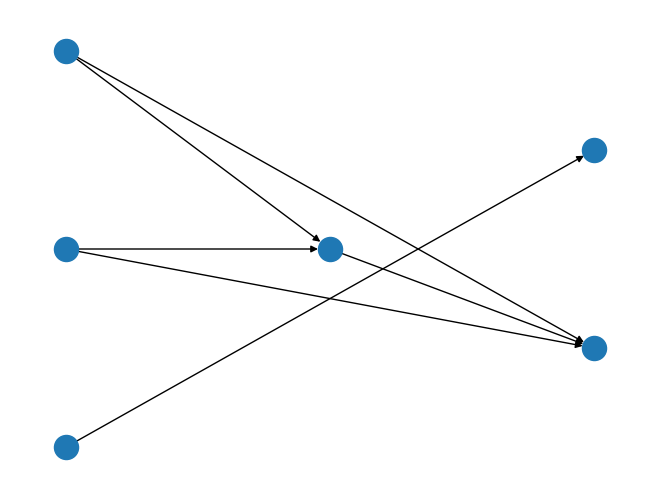

In [15]:
n_outputs = 2
n_inputs = 3
g = nx.DiGraph()
for name in range(-n_inputs, 0):
    g.add_node(name, node_type=0)
for name in winner.nodes.keys():
    if name < n_outputs:
        node_type = 2
    else:
        node_type = 1
    g.add_node(name, node_type=node_type)
for i,j in winner.connections.keys():
    g.add_edge(i, j)
pos = nx.multipartite_layout(g, subset_key="node_type")
nx.draw(g, pos=pos)